In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, median_abs_deviation


def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'utility.py').exists():
            return p
    return start


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / 'data'
LEGACY_DATA_DIR = Path('/raid/home/smrutip/smruti_project')


def resolve_input_file(filename: str) -> Path:
    candidates = [
        Path(filename),
        BASE_DIR / filename,
        DATA_DIR / filename,
        LEGACY_DATA_DIR / filename,
    ]
    for c in candidates:
        if c.exists():
            return c

    # Fallback: search within current tree and BASE_DIR tree.
    search_roots = [Path.cwd(), BASE_DIR]
    seen = set()
    for root in search_roots:
        root = root.resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]

    searched = '\n'.join(str(c) for c in candidates)
    raise FileNotFoundError(f'Could not find input file: {filename}\nSearched:\n{searched}')


def read_excel_input(filename: str, **kwargs) -> pd.DataFrame:
    return pd.read_excel(resolve_input_file(filename), **kwargs)


def compute_cohens_d(group1, group2):
    g1 = pd.Series(group1).dropna().to_numpy(dtype=float)
    g2 = pd.Series(group2).dropna().to_numpy(dtype=float)
    if len(g1) < 2 or len(g2) < 2:
        return np.nan
    s1 = np.var(g1, ddof=1)
    s2 = np.var(g2, ddof=1)
    pooled = np.sqrt(((len(g1) - 1) * s1 + (len(g2) - 1) * s2) / (len(g1) + len(g2) - 2))
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (np.mean(g1) - np.mean(g2)) / pooled


# Import utility after PROJECT_ROOT is on sys.path.
import utility


##### Fig 7d plot

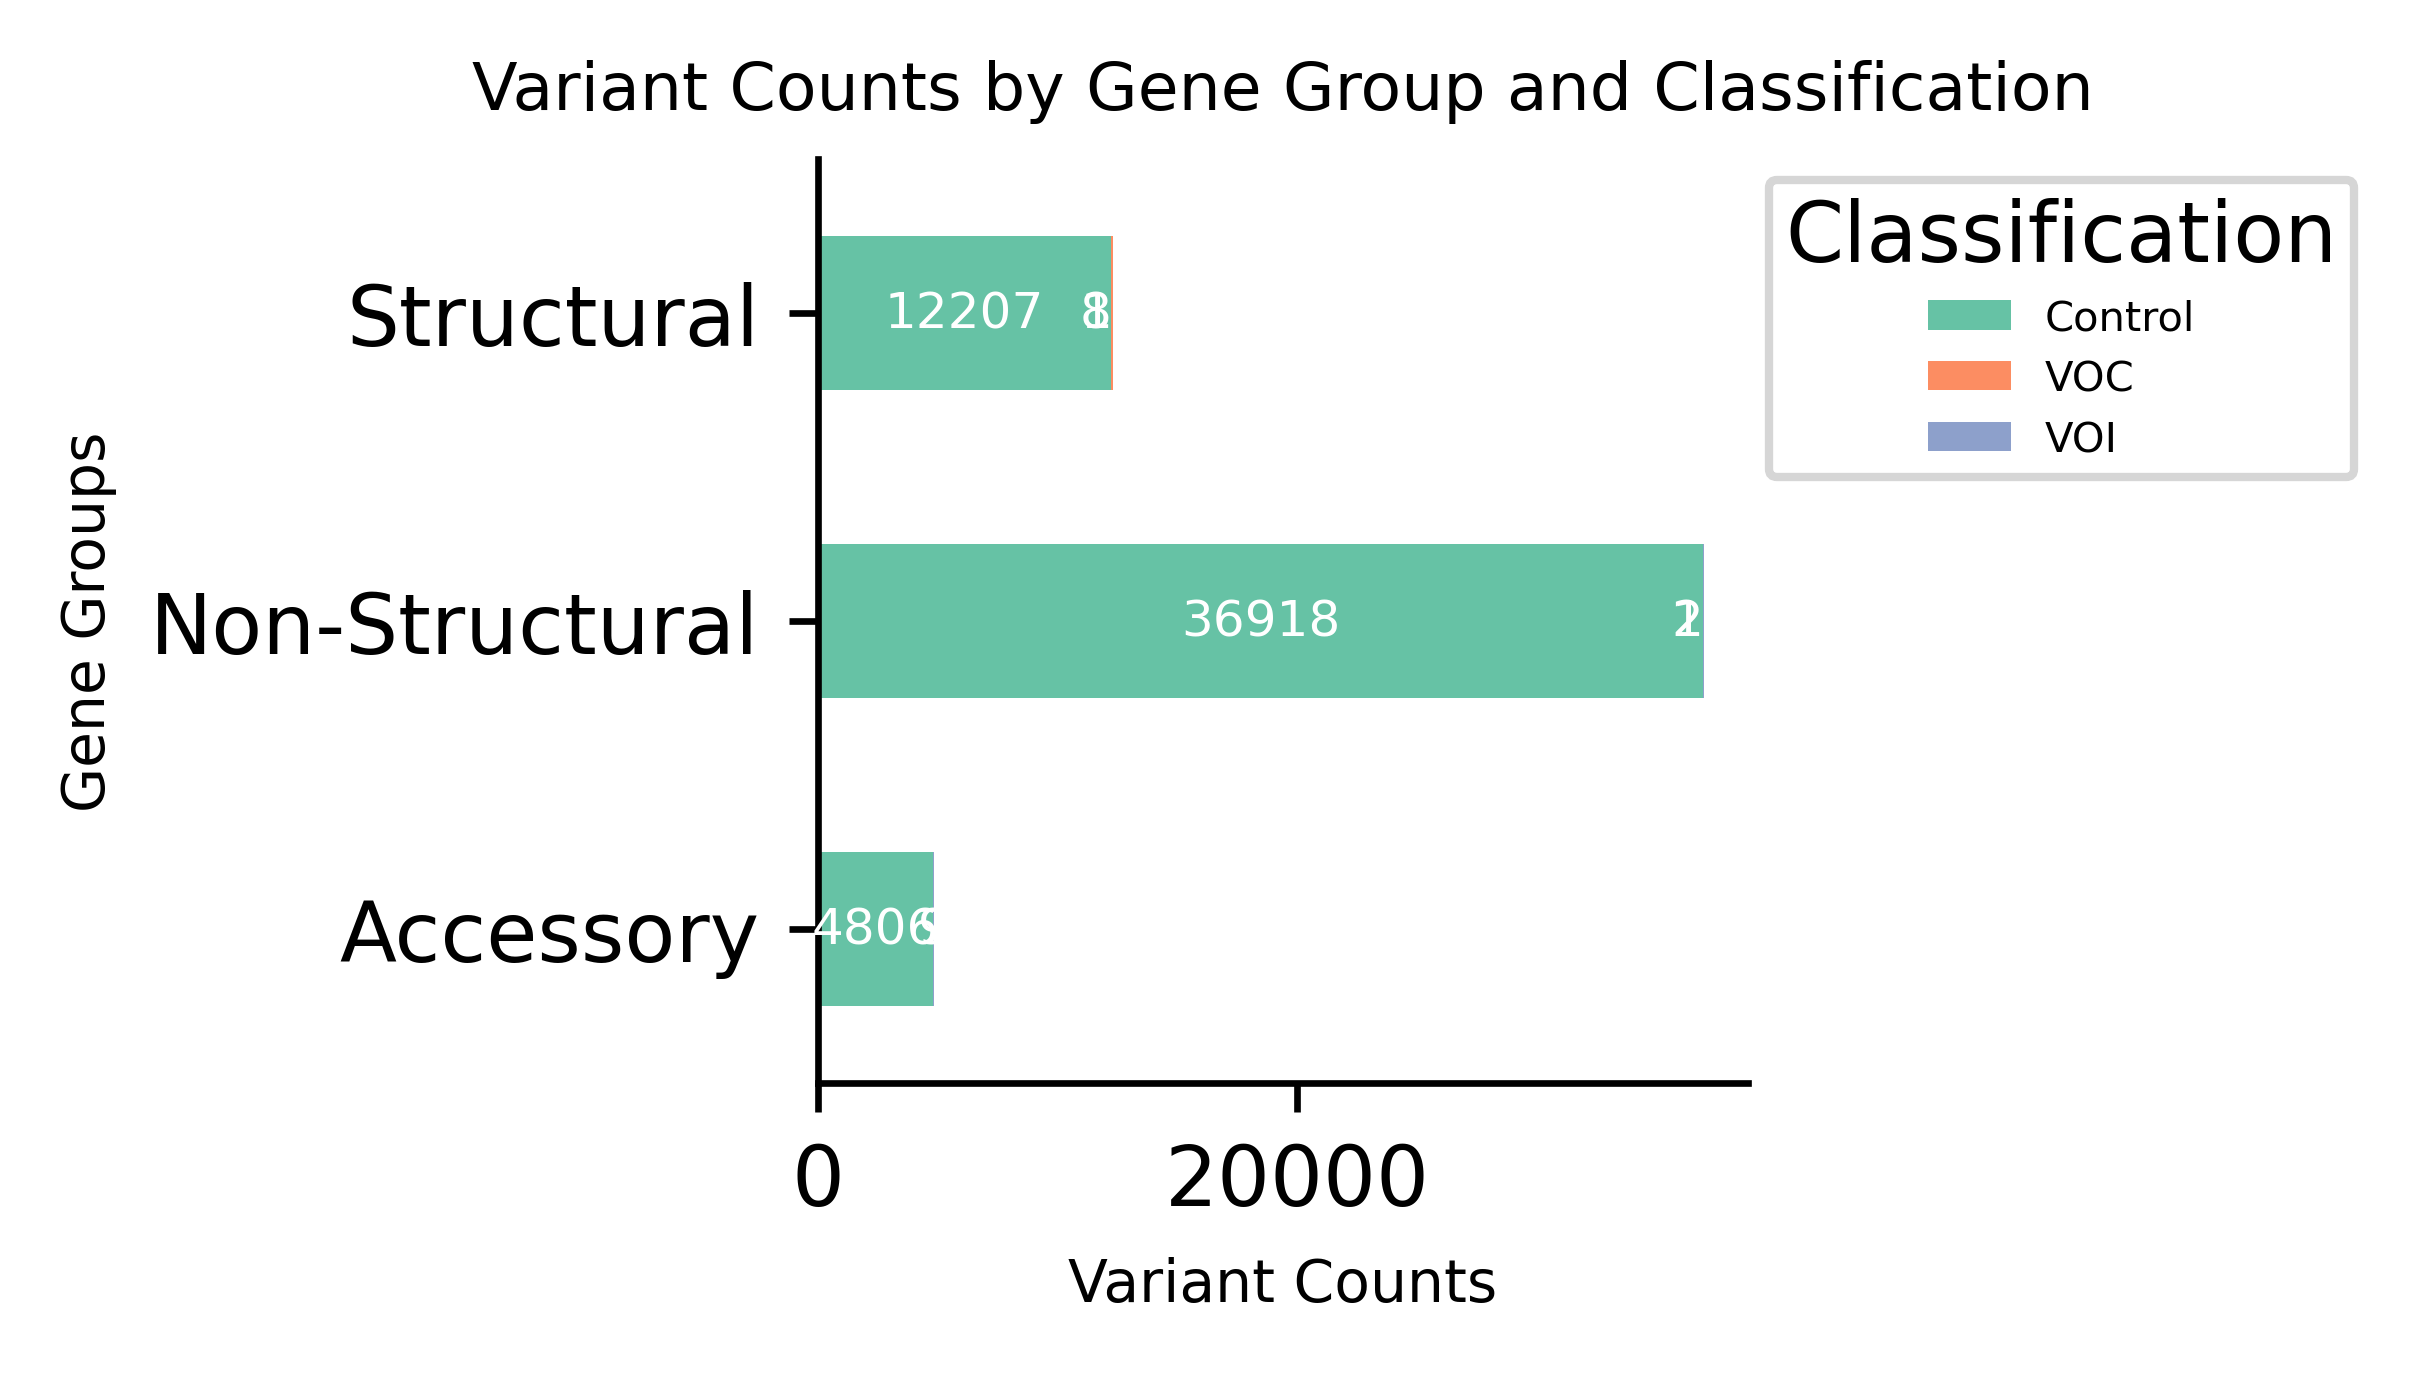

In [2]:
# Load dataset with robust path resolution
df = read_excel_input('COVID_final_mastersheet.xlsx')

# Define gene groups
structural_genes = ['S', 'E', 'M', 'N']
non_structural_genes = ['ORF1ab']
accessory_genes = ['ORF10', 'ORF3a', 'ORF6', 'ORF7a', 'ORF7b', 'ORF8']


def categorize_gene(gene):
    if gene in structural_genes:
        return 'Structural'
    if gene in non_structural_genes:
        return 'Non-Structural'
    if gene in accessory_genes:
        return 'Accessory'
    return 'Unknown'


df['Gene Group'] = df['Gene'].apply(categorize_gene)
grouped_df = df.groupby(['Gene Group', 'Classification']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(2, 2), dpi=600)

# Colors correspond to stacked columns (Classification), not row index.
classification_palette = dict(zip(grouped_df.columns, sns.color_palette('Set2', n_colors=len(grouped_df.columns))))
stack_colors = [classification_palette[col] for col in grouped_df.columns]

grouped_df.plot(kind='barh', stacked=True, color=stack_colors, ax=ax)

ax.set_title('Variant Counts by Gene Group and Classification', fontsize=8)
ax.set_ylabel('Gene Groups', fontsize=7)
ax.set_xlabel('Variant Counts', fontsize=7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', fontsize=6, color='white')

ax.legend(title='Classification', fontsize=5, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


#### Fig 7e plot

Label=Structural, p_raw=1.10e-02, p_reported=1.66e-02, effect size=3.63e-01, 95% CI [1.19e-01, 7.87e-01]
Label=Non-structural, p_raw=1.19e-01, p_reported=1.19e-01, effect size=2.36e-01, 95% CI [-2.67e-01, 1.13e+00]
Label=Accessory, p_raw=1.57e-03, p_reported=4.72e-03, effect size=1.21e+00, 95% CI [3.10e-01, 1.68e+00]
         category    x_column          y_column            hue_column  \
0       Accessory  Gene_Group  accumulated_gain  classification_group   
1  Non-structural  Gene_Group  accumulated_gain  classification_group   
2      Structural  Gene_Group  accumulated_gain  classification_group   

  group1_name group2_name  n_group1  n_group2            test alternative  \
0     VOC/VOI     Control        16      4806  Mann-Whitney U     greater   
1     VOC/VOI     Control        33     36918  Mann-Whitney U     greater   
2     VOC/VOI     Control        95     12207  Mann-Whitney U     greater   

        effect_size_name  effect_size  ci_level    ci_low   ci_high     p_raw  

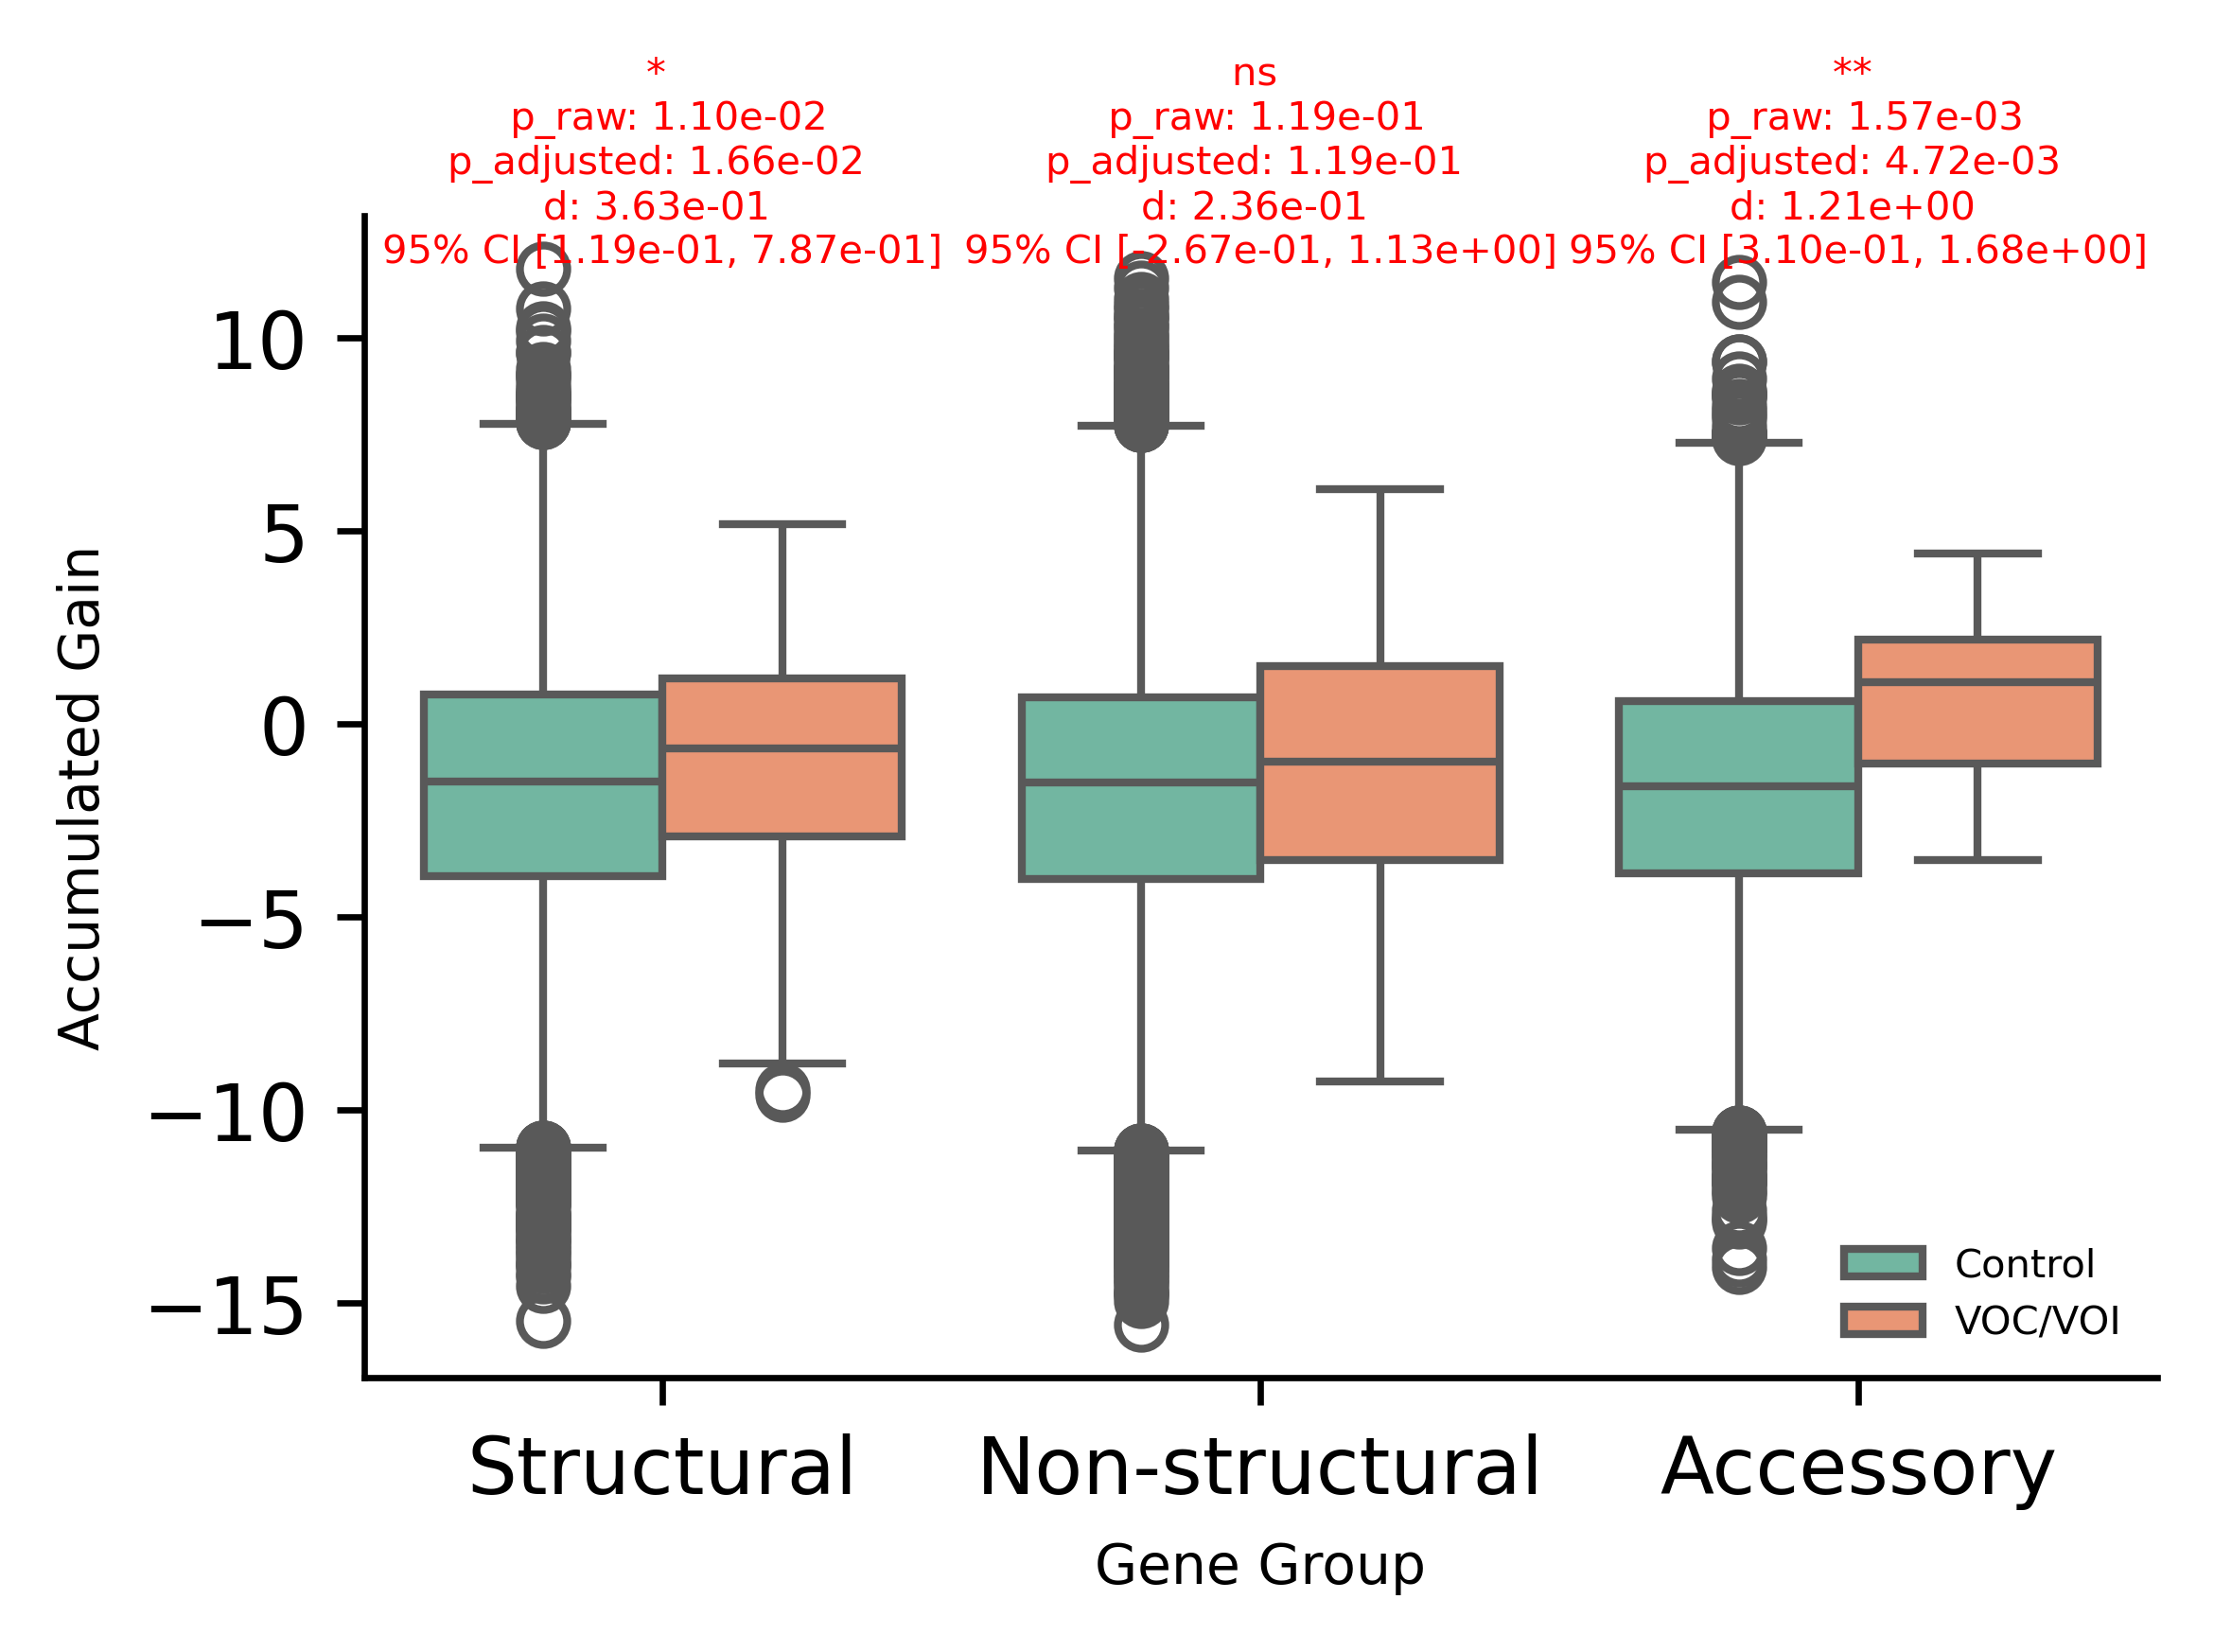

In [3]:
df = read_excel_input('COVID_final_mastersheet.xlsx')
df['classification_group'] = df['Classification'].apply(lambda x: 'VOC/VOI' if x in ['VOC', 'VOI'] else 'Control')

structural_genes = ['S', 'E', 'M', 'N']
non_structural_gene = ['ORF1ab']
accessory_genes = df['Gene'].unique()
for gene in structural_genes + non_structural_gene:
    accessory_genes = accessory_genes[accessory_genes != gene]

gene_group_mapping = {gene: 'Structural' for gene in structural_genes}
gene_group_mapping[non_structural_gene[0]] = 'Non-structural'
for gene in accessory_genes:
    gene_group_mapping[gene] = 'Accessory'

df['Gene_Group'] = df['Gene'].map(gene_group_mapping)
df = df.dropna(subset=['Gene_Group', 'classification_group', 'accumulated_gain']).copy()

gene_order = ['Structural', 'Non-structural', 'Accessory']

fig, ax = plt.subplots(dpi=600, figsize=(4, 3))
sns.boxplot(
    data=df,
    x='Gene_Group',
    y='accumulated_gain',
    hue='classification_group',
    order=gene_order,
    hue_order=['Control', 'VOC/VOI'],
    ax=ax,
    palette='Set2'
)

ax = utility.return_box_with_p_effect_size(
    ax=ax,
    data=df,
    x_columns='Gene_Group',
    y_columns='accumulated_gain',
    group1_name='VOC/VOI',
    group2_name='Control',
    y_pos=float(df['accumulated_gain'].max()) + 0.15,
    hue_columns='classification_group',
    fontsize=5,
    p_adjust_method='fdr_bh',
    alternative='greater'
)

stats_gene_group = utility.summarize_boxplot_pairwise_stats(
    data=df,
    x_columns='Gene_Group',
    y_columns='accumulated_gain',
    group1_name='VOC/VOI',
    group2_name='Control',
    hue_columns='classification_group',
    p_adjust_method='fdr_bh',
    alternative='greater'
)
print(stats_gene_group)
stats_gene_group.to_csv(BASE_DIR / 'gene_group_stats.csv', index=False)

ax.legend(fontsize=5, frameon=False)
ax.set_ylabel('Accumulated Gain', fontsize=7)
ax.set_xlabel('Gene Group', fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Fig 7f plot

/tmp/ipykernel_2497939/2366904314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group', y='accumulated_gain', order=['Control', 'Variant'], ax=ax, palette='Set2')


P-value = 2.29e-04, effect size = 5.12e-01, 95% CI [2.34e-01, 8.63e-01]
  category x_column          y_column hue_column group1_name group2_name  \
0  overall    group  accumulated_gain       None     Variant     Control   

   n_group1  n_group2            test alternative       effect_size_name  \
0       144     53931  Mann-Whitney U     greater  median_based_distance   

   effect_size  ci_level    ci_low   ci_high     p_raw p_adjust_method  \
0     0.512165        95  0.234113  0.862616  0.000229            none   

   p_adjusted  
0    0.000229  


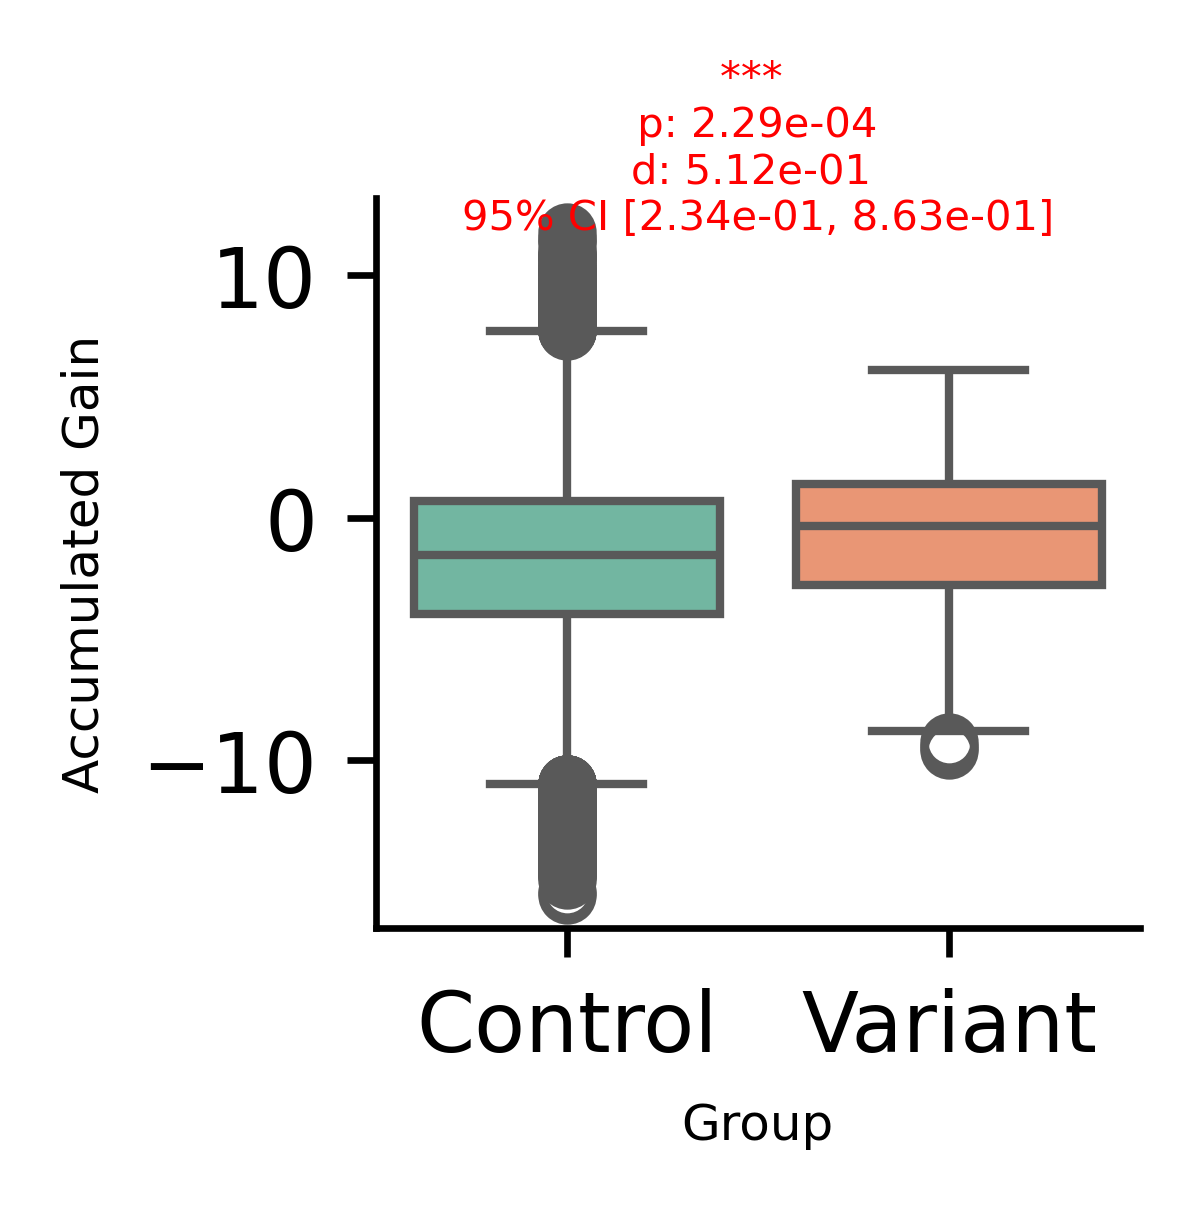

In [4]:
df = read_excel_input('COVID_final_mastersheet.xlsx')
df['group'] = df['Classification'].apply(lambda x: 'Variant' if x in ['VOC', 'VOI'] else 'Control')
df = df.dropna(subset=['group', 'accumulated_gain']).copy()

fig, ax = plt.subplots(1, 1, dpi=600, figsize=(2.1, 2.1))
sns.boxplot(data=df, x='group', y='accumulated_gain', order=['Control', 'Variant'], ax=ax, palette='Set2')

ax = utility.return_box_with_p_effect_size(
    ax=ax,
    data=df,
    x_columns='group',
    y_columns='accumulated_gain',
    group1_name='Variant',
    group2_name='Control',
    y_pos=float(df['accumulated_gain'].max()) + 0.12,
    fontsize=5,
    p_adjust_method=None,
    alternative='greater'
)

stats_variant_control = utility.summarize_boxplot_pairwise_stats(
    data=df,
    x_columns='group',
    y_columns='accumulated_gain',
    group1_name='Variant',
    group2_name='Control',
    p_adjust_method=None,
    alternative='greater'
)
print(stats_variant_control)

ax.set_ylabel('Accumulated Gain', fontsize=6)
ax.set_xlabel('Group', fontsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Fig 7g

/tmp/ipykernel_2497939/148724517.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kGain_category', y='log_mutation_freq', order=['< 0', '≥ 0'], palette='Set2', ax=ax)


P-value = 3.90e-87, effect size = 2.58e-01, 95% CI [2.22e-01, 2.94e-01]
  category        x_column           y_column hue_column group1_name  \
0  overall  kGain_category  log_mutation_freq       None         ≥ 0   

  group2_name  n_group1  n_group2            test alternative  \
0         < 0     17502     36573  Mann-Whitney U     greater   

        effect_size_name  effect_size  ci_level    ci_low   ci_high  \
0  median_based_distance     0.258247        95  0.221879  0.294082   

          p_raw p_adjust_method    p_adjusted  
0  3.897874e-87            none  3.897874e-87  


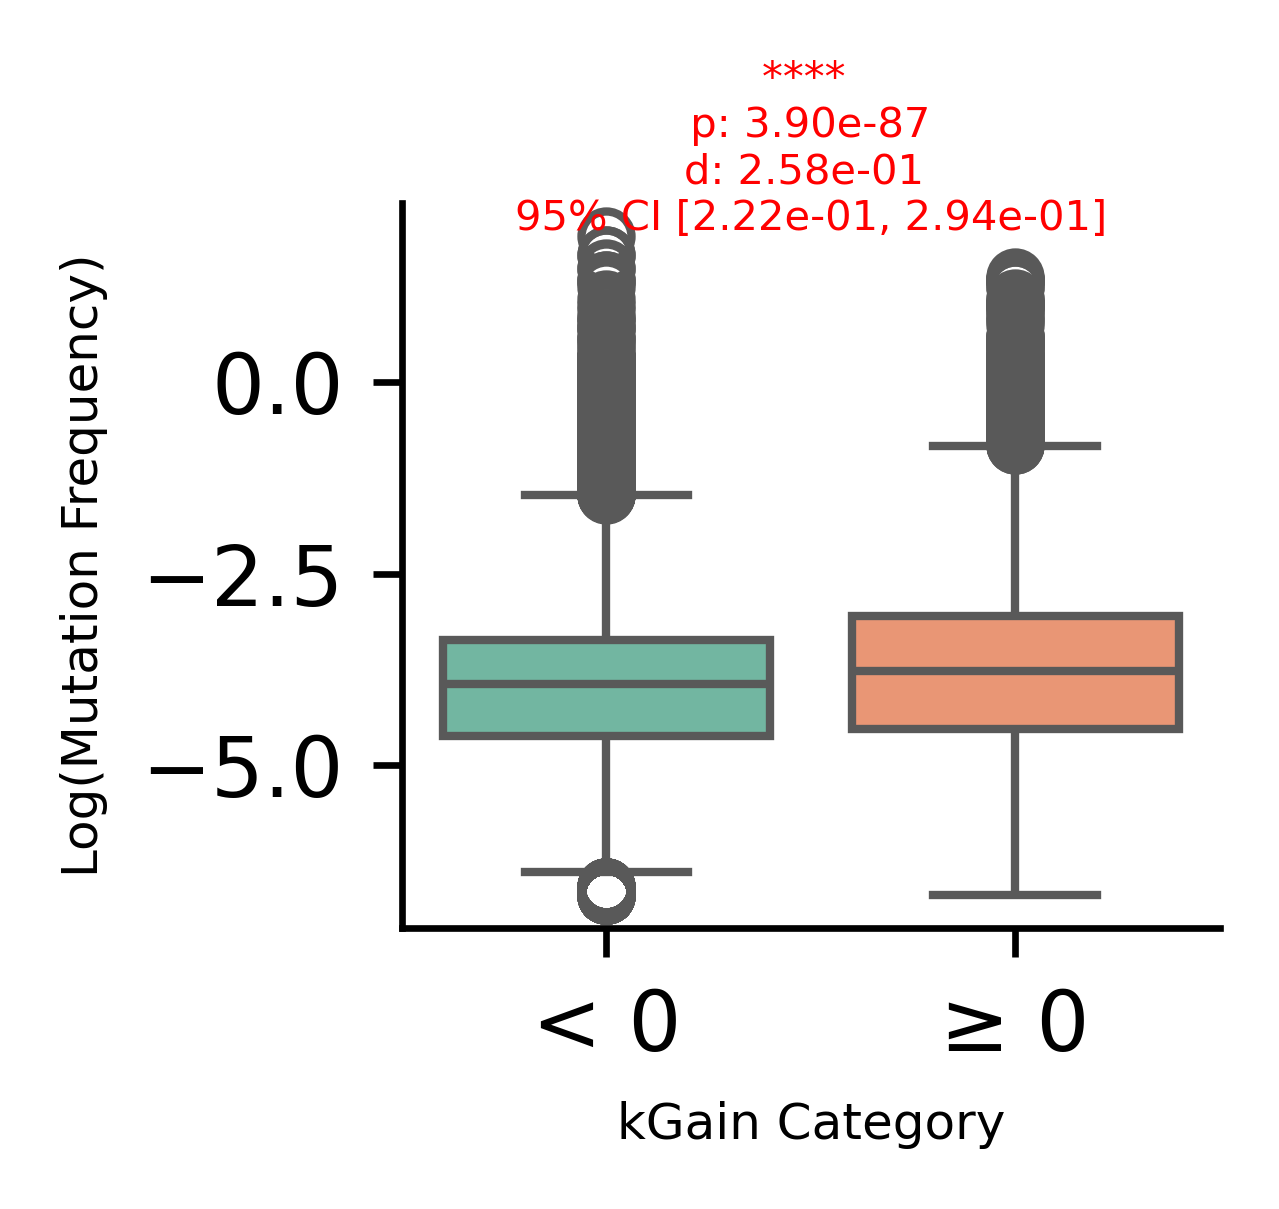

In [5]:
df = read_excel_input('COVID_final_mastersheet.xlsx')
df = df[['accumulated_gain', 'mutation freq']].dropna().copy()

df['kGain_category'] = df['accumulated_gain'].apply(lambda x: '< 0' if x < 0 else '≥ 0')
df['log_mutation_freq'] = df['mutation freq'].apply(lambda x: 0 if x == 0 else np.log10(x))

fig, ax = plt.subplots(1, 1, dpi=600, figsize=(2.1, 2.1))
sns.boxplot(data=df, x='kGain_category', y='log_mutation_freq', order=['< 0', '≥ 0'], palette='Set2', ax=ax)

ax = utility.return_box_with_p_effect_size(
    ax=ax,
    data=df,
    x_columns='kGain_category',
    y_columns='log_mutation_freq',
    group1_name='≥ 0',
    group2_name='< 0',
    y_pos=float(df['log_mutation_freq'].max()) + 0.08,
    fontsize=5,
    p_adjust_method=None,
    alternative='greater'
)

stats_kgain_freq = utility.summarize_boxplot_pairwise_stats(
    data=df,
    x_columns='kGain_category',
    y_columns='log_mutation_freq',
    group1_name='≥ 0',
    group2_name='< 0',
    p_adjust_method=None,
    alternative='greater'
)
print(stats_kgain_freq)

ax.set_ylabel('Log(Mutation Frequency)', fontsize=6)
ax.set_xlabel('kGain Category', fontsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
